In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np

from laser import *

data_root = "/datax/scratch/ktp/carmenes-lasers/spectra/extracted/"
dir_list = glob.glob(data_root + "/*")

diridx = 10

dir_path = dir_list[diridx]


In [2]:
from tqdm import tqdm 

all_alph, all_wls, all_nobs = get_uni_thresh_ingredients(dir_list)

common_wg, alpha_uni = get_uni_thresh(all_alph, all_wls, all_nobs, 
                                      common_wg=None)



100%|████████████████████████████████████████████████████████████████████████| 362/362 [01:15<00:00,  4.79it/s]


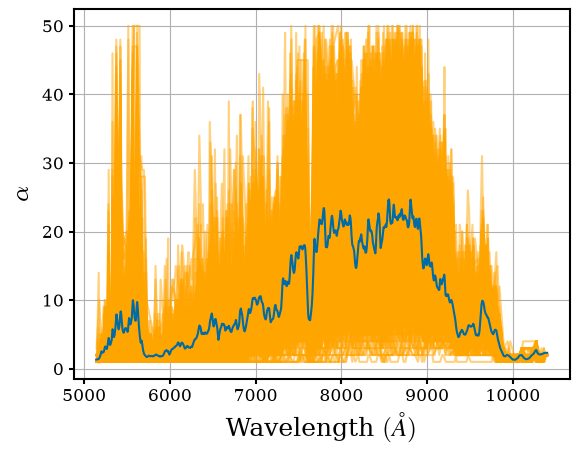

In [3]:
for wls, alph in zip(all_wls, all_alph):
    plt.plot(wls, alph, alpha=0.5, color='orange')
plt.plot(common_wg, alpha_uni)
plt.xlabel('Wavelength $(\\AA)$')
plt.ylabel('$\\alpha$')
plt.grid()

In [4]:
print(len(all_alph))

362


In [6]:
from astropy import units as u
from tqdm import tqdm

from power import *
from load_data import load_star

def mode(a):
    u, c = np.unique(a, return_counts=True)
    m = u[np.argmax(c)] 

    return m

def in_bounds(arr, low=-90, high=90):
    # a_normalized = np.empty_like(arr)
    # for i, a in enumerate(arr):
    #     if a > 90:
    #         a_normalized[i] = 180 - a
    #     elif a < -90:
    #         a_normalized[i] = -180 - a
    #     else:
    #         a_normalized[i] = a
        
    return arr[(arr > low) & (arr < high)]

delta_lambda=5000
d_t=3.5 * 1e10
W_LSF=0.056

all_power = []
skipidx = []
for staridx, (dir_path, alph, wls) in tqdm(enumerate(zip(dir_list, all_alph, all_wls))):
    # staridx = 0
    # dir_path, alph, wls = dir_list[0], all_alph[0], all_wls[0]
    
    base_path = dir_path + "/base_peaks"
    base_list = glob.glob(base_path + "/*")
    
    wavestack, polystack, thresholdstack = [], [], []
    for obsidx in range(len(base_list)):
        base_peaks = np.load(base_list[obsidx], 
                             allow_pickle=True)['arr_0']
        
        # should deal with overlap later.. or not necessary if going by order?
        obswave = np.concatenate([base_peaks[ordidx]['wave'] for ordidx in range(len(base_peaks))])
        obspoly = np.concatenate([base_peaks[ordidx]['poly'] for ordidx in range(len(base_peaks))])
        obsthreshold = np.concatenate([base_peaks[ordidx]['threshold'] for ordidx in range(len(base_peaks))])
    
        wavestack.append(obswave)
        polystack.append(obspoly)
        thresholdstack.append(obsthreshold)
    
    wavestack = np.array(wavestack)
    polystack = np.array(polystack)
    thresholdstack = np.array(thresholdstack)
    
    starwave = np.median(wavestack, axis=0)
    polywave = np.median(polystack, axis=0)
    thresholdwave = np.median(thresholdstack, axis=0)
    
    staralpha = np.interp(starwave, wls, alph)
    
    # power calculation
    sigma = thresholdwave - polywave
    
    starvals = load_star(dir_path)
    # rain, decin = in_bounds(starvals[5]), in_bounds(starvals[6])
    # if len(rain) < 1:
    #     print("coordinates?")
    #     print(starvals[5], starvals[6])
    #     print(f"skip {base_path}")
    #     skipidx.append(staridx)
    #     continue
    ra, dec = mode(starvals[5]), mode(in_bounds(starvals[6]))
    print(ra, dec)
    gaia = gaia_query(ra, dec, radius=10*u.arcsec)

    # print(gaia)
    # gaia = gaia[0]
    # print(gaia)
    lum, lum_err = gaia_to_lum(gaia)

    if len(lum) < 1:
        print(ra, dec)
        # print(lum)
        print(f"skip {base_path}")
        skipidx.append(staridx)
        continue
    if len(lum) > 1: 
        # print(lum)
        lum = lum[0]
        # print(lum)

    power = phan_eq9(lum, starwave, 
                 delta_lambda, d_t, 
                 W_LSF, staralpha, sigma)

    all_power.append(power)

# print(wavestack.shape)
# plt.scatter(starwave, polywave, s=5)
# plt.scatter(starwave, thresholdwave, s=5)
# plt.scatter(starwave, staralpha * (thresholdwave - polywave), s=5)

0it [00:00, ?it/s]

1.30075 45.7858611111111


1it [00:06,  6.61s/it]

1.67641666666667 -7.54619444444444


2it [00:12,  6.47s/it]

...

30.3945 63.7695277777778


25it [02:04,  4.26s/it]

31.7676666666667 49.6435833333333


25it [05:54, 14.17s/it]


HTTPError: Error 408: 
Job timeout/aborted.


In [ ]:
np.savez("power.npy", all_power)

In [ ]:
all_power_vals = [power.value for power in all_power]
med_alphs, nstar_pass = alpha_nstar_rates(all_power_vals)

print(len(med_alphs), len(nstar_pass))

plt.scatter(med_alphs, nstar_pass)
plt.ylabel('$N_{\\star}$')
plt.xlabel('Median Power (W)')
plt.xscale('log')
plt.grid()
plt.show()

In [ ]:
med_alphs, nstar_pass = alpha_nstar_rates(all_alph)
print(len(all_power))

In [ ]:
plt.scatter(starwave, power/1000, s=5)
plt.yscale('log')
plt.ylabel('kW')

print(np.median(power))

In [ ]:
med_alphs, nstar_pass = alpha_nstar_rates(all_alph)

In [ ]:
print(med_alphs.shape)

In [ ]:
print(len(med_alphs), len(nstar_pass))

plt.scatter(med_alphs, nstar_pass)
plt.ylabel('$N_{\\star}$')
plt.xlabel('$\\bar{\\alpha}$')
plt.grid()
plt.show()

In [2]:
from tqdm import tqdm

total_count = 0

all_wave, all_flux = [], []
for dir_path in tqdm(dir_list):
    pass_list = glob.glob(dir_path + "/peaks_pass/*")

    for passidx, pass_file in enumerate(pass_list):
        pass_data = np.load(pass_file, allow_pickle=True)
        pass_wave, pass_flux = pass_data['wave'], pass_data['flux']
        count = sum(len(arr) for arr in pass_wave)
        # print(count, f" peaks in {pass_file}")
        total_count += count
        all_wave.append(pass_wave)
        all_flux.append(pass_flux)

print(total_count)

100%|████████████████████████████████████████████████████████████████████████████████| 362/362 [00:25<00:00, 13.93it/s]

178650


In [3]:
flat_wave = np.hstack(np.hstack(all_wave))
flat_flux = np.hstack(np.hstack(all_flux))



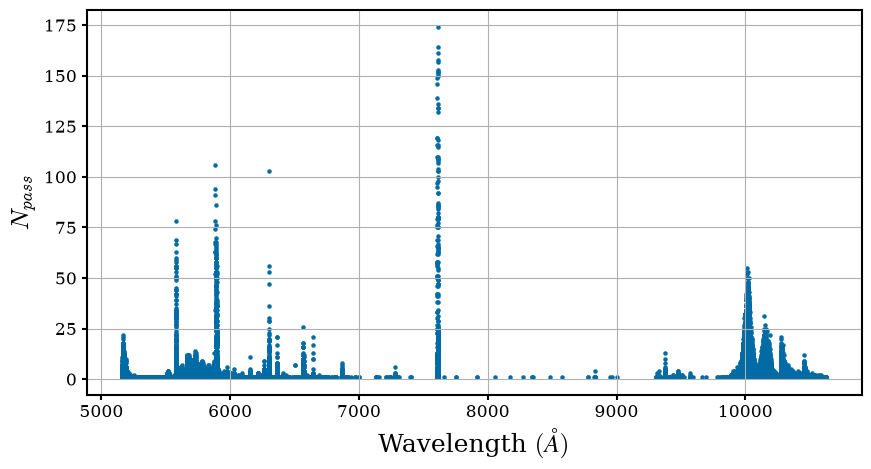

In [4]:
unique_vals, counts = np.unique(flat_wave, return_counts=True)

# Sort by counts in descending order (most common first)
sorted_indices = np.argsort(-counts)
sorted_vals = unique_vals[sorted_indices]
sorted_counts = counts[sorted_indices]


plt.figure(figsize=(10, 5))
plt.scatter(sorted_vals, sorted_counts, s=5)
plt.ylabel('$N_{pass}$')
plt.xlabel('Wavelength $(\\AA)$')
plt.grid()

In [5]:
repeat_mask = (sorted_counts < 3)
norepvals, norepcts = sorted_vals[repeat_mask], sorted_counts[repeat_mask]

print(len(norepvals))

import numpy as np

def filter_isolated_points(norepvals, distance_threshold):

    norepvals = np.asarray(norepvals)
    
    # Compute pairwise absolute differences
    # Shape: (n, n) where [i, j] is |norepvals[i] - norepvals[j]|
    diff = np.abs(norepvals[:, np.newaxis] - norepvals[np.newaxis, :])
    
    # Set diagonal to infinity (exclude self-comparison)
    np.fill_diagonal(diff, np.inf)
    
    # For each point, check if it has any neighbor within threshold
    has_neighbor = np.any(diff < distance_threshold, axis=1)
    
    # Keep points that DON'T have neighbors
    keep_indices = np.where(~has_neighbor)[0]
    
    return keep_indices

keep_indices = filter_isolated_points(norepvals, 3*0.056)
noclosevals, noclosects = norepvals[keep_indices], norepcts[keep_indices]

print(len(noclosevals))

33231
922


In [75]:
low_wl, high_wl = 6000, 6500
wl_filter = (noclosevals > low_wl) & (noclosevals < high_wl)
print(noclosevals[wl_filter])

[6015.01025641 6057.46153846 6364.89487179 6431.83260073 6459.41587302
 6460.09047619 6476.51501832 6488.8956044  6451.91428571 6452.50793651
 6454.         6454.20793651 6457.71587302 6458.25555556 6458.7952381
 6409.77863248 6420.69487179 6421.77838828 6431.27106227 6450.4031746
 6450.83492063 6391.61575092 6391.85641026 6393.75494505 6395.51978022
 6396.26849817 6396.96373626 6407.95042735 6408.26837607 6374.59230769
 6377.98376068 6384.87728938 6386.08058608 6389.18241758 6327.48290598
 6327.88034188 6328.67521368 6330.13247863 6341.0969475  6341.97203907
 6345.42051282 6355.72735043 6358.69487179 6364.20598291 6364.52393162
 6308.86605617 6314.60598291 6317.97094017 6319.34871795 6319.87680098
 6320.32905983 6320.67350427 6321.6008547  6324.7008547  6325.01880342
 6325.9991453  6307.66410256 6308.08217338 6308.42185592 6283.07631258
 6286.84884005 6287.38766789 6288.66800977 6289.42857143 6291.04578755
 6292.37838828 6277.69365079 6278.86630037 6280.10598291 6281.07643468
 6267.95

In [76]:
def find_value_in_wave(all_wave, value):

    matches = []
    
    for n in range(len(all_wave)):
        for m in range(len(all_wave[n])):
            if value in all_wave[n][m]:
                matches.append((n, m))
    
    return matches if matches else None

match = find_value_in_wave(all_wave, noclosevals[wl_filter][-1])

In [77]:
print(match)

[(18564, 16)]


In [78]:
def find_directory_for_obs(dir_list, target_obs):

    cumulative_count = 0
    
    for dir_path in dir_list:
        pass_list = glob.glob(dir_path + "/peaks_pass/*")
        
        for passidx, pass_file in enumerate(pass_list):
            cumulative_count += 1
            
            if target_obs == cumulative_count:
                return dir_path, passidx
    
    return None

dir_path, passidx = find_directory_for_obs(dir_list, match[0][0])

print(dir_path, passidx)

/datax/scratch/ktp/carmenes-lasers/spectra/extracted/J23064-050_VIS 188


(61, 4096, 198)


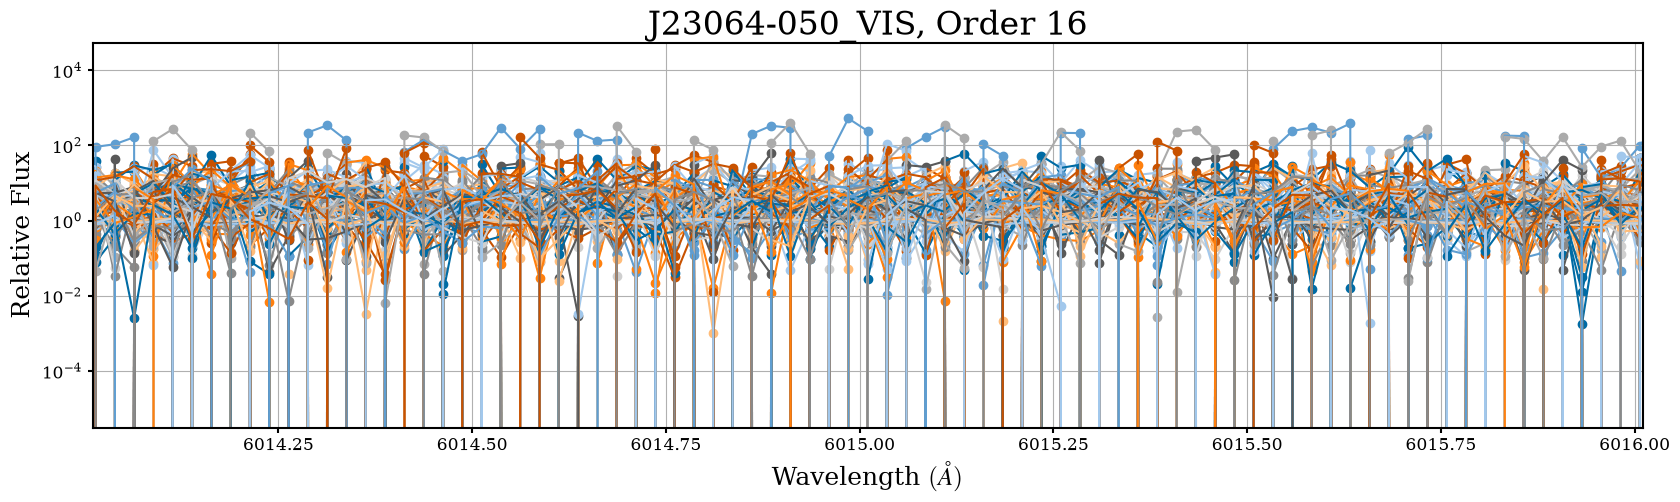

In [81]:
star_name = dir_path.split("extracted/")[-1]
results = np.load(dir_path + "/results.npz")

wave_arr = results['new_wave_arr']
flux_arr = results['normalized_spec']

idxs = range(wave_arr.shape[2]) #[passidx, passidx+1, passidx+2]

plt.figure(figsize=(20, 5))

for i, idx in enumerate(idxs): 
    wave = wave_arr[match[0][-1], :, idx]
    flux = flux_arr[match[0][-1], :, idx]
    
    plt.scatter(wave, flux, label=f"Observation {idx}")
    plt.plot(wave, flux)

plt.xlim(noclosevals[wl_filter][0] - 1, noclosevals[wl_filter][0] + 1)

plt.yscale('log')
plt.xlabel('Wavelength $(\\AA)$')
plt.ylabel('Relative Flux')
plt.title(star_name + f", Order {match[0][-1]}")

# plt.vlines(noclosevals[wl_filter][0], -20, 60, linestyle='dashdot')
plt.grid()
# plt.legend()
print(wave_arr.shape)

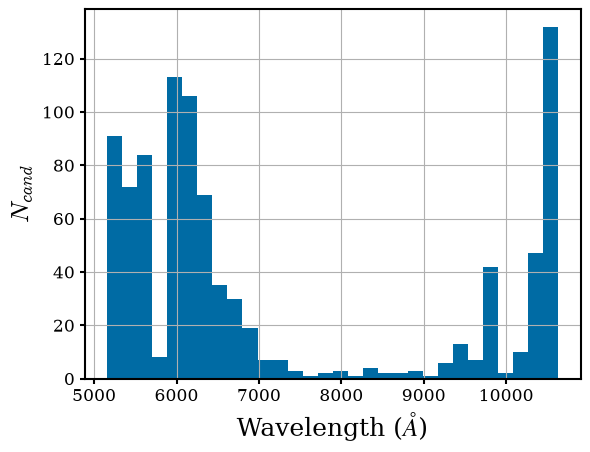

In [6]:
plt.hist(noclosevals, bins=30)
plt.xlabel('Wavelength ($\\AA$)')
plt.ylabel('$N_{cand}$')
plt.grid()
plt.show()

In [7]:
# View results
rounded_wave = np.round(flat_wave, 3)

round_unique_vals, round_counts = np.unique(rounded_wave, return_counts=True)

# Sort by counts in descending order (most common first)
round_sorted_indices = np.argsort(-round_counts)
round_sorted_vals = round_unique_vals[round_sorted_indices]
round_sorted_counts = round_counts[round_sorted_indices]

for val, count in zip(round_sorted_vals, round_sorted_counts):
    print(f"{val}: {count} occurrences")

7611.531: 174 occurrences
7611.906: 172 occurrences
7610.156: 161 occurrences
7611.812: 161 occurrences
7611.937: 158 occurrences
7610.781: 158 occurrences
7611.469: 157 occurrences
7611.5: 152 occurrences
7610.656: 152 occurrences
7610.281: 150 occurrences
7609.468: 149 occurrences
7609.406: 146 occurrences
7609.531: 139 occurrences
7610.687: 136 occurrences
7611.0: 134 occurrences
7611.562: 134 occurrences
7611.781: 132 occurrences
7609.156: 119 occurrences
7609.343: 119 occurrences
7610.187: 118 occurrences
7609.281: 116 occurrences
7610.312: 116 occurrences
7611.25: 115 occurrences
7610.437: 110 occurrences
7609.593: 110 occurrences
7610.25: 109 occurrences
7611.406: 109 occurrences
7610.093: 108 occurrences
7610.812: 107 occurrences
5885.549: 106 occurrences
7609.906: 104 occurrences
7611.375: 103 occurrences
6301.445: 103 occurrences
7610.562: 103 occurrences
7610.218: 100 occurrences
7611.875: 98 occurrences
7609.218: 97 occurrences
7609.656: 95 occurrences
5885.574: 95 occurren